In [1]:
import kagglehub
import json
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder,
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import f1_score, confusion_matrix

from regression_task_preprocessing import WeatherImputer, fix_season, filter_invalid, drop_unnecessary_columns

c:\Users\glebo\Documents\University\Machine Learning\project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open("../kaggle_token.json", "r") as f:
    kaggle_acc = json.load(f)

os.environ["KAGGLE_USERNAME"] = kaggle_acc["username"]
os.environ["KAGGLE_KEY"] = kaggle_acc["key"]

path = kagglehub.competition_download('ud-s-machine-learning-2026-classification')

print("Path to competition files:", path)

Path to competition files: C:\Users\glebo\.cache\kagglehub\competitions\ud-s-machine-learning-2026-classification


In [3]:
train = pd.read_csv(path+"/train.csv")

TARGET = "Demand_Category"

# train = train.dropna()

X = train.drop(columns=[TARGET, "Kaggle_ID", "Record_id"])

y_raw = train[TARGET]

train.head(2)


,Kaggle_ID,Date,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,Record_id,Demand_Category
0,0,15/05/2018,11,24.8,36,1.8,973,8.7,2.7,0.0,0.0,Sprng,No Holiday,Yes,5137441,1
1,1,7/9/2018,23,12.9,0,2.4,1688,50.9,0.0,2.4,1.4,Sproing,No Holiday,No,1465289,0


In [4]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.mixture import GaussianMixture
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from scipy.special import logsumexp


class GMMClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_components=1, covariance_type="full", random_state=None,
                 reg_covar=1e-6, max_iter=200):
        self.n_components = n_components
        self.covariance_type = covariance_type
        self.random_state = random_state
        self.reg_covar = reg_covar
        self.max_iter = max_iter

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.classes_ = np.unique(y)

        # allow either a single int (same n_components for every class)
        # or a dict {class_label: n_components}
        if isinstance(self.n_components, dict):
            n_comp_for = self.n_components
        else:
            n_comp_for = {c: self.n_components for c in self.classes_}

        self.mixtures_ = {}
        self.priors_ = {}
        n_total = len(y)

        for c in self.classes_:
            X_c = X[y == c]
            self.priors_[c] = len(X_c) / n_total

            gmm = GaussianMixture(
                n_components=n_comp_for[c],
                covariance_type=self.covariance_type,
                reg_covar=self.reg_covar,
                max_iter=self.max_iter,
                random_state=self.random_state,
            )
            gmm.fit(X_c)
            self.mixtures_[c] = gmm

        return self

    def _joint_log_likelihood(self, X):
        # log[ prior(c) * p(x | mixture_c) ] for every class, shape (n_samples, n_classes)
        X = check_array(X)
        logs = np.column_stack([
            self.mixtures_[c].score_samples(X) + np.log(self.priors_[c])
            for c in self.classes_
        ])
        return logs

    def predict_proba(self, X):
        check_is_fitted(self, "mixtures_")
        joint = self._joint_log_likelihood(X)
        log_norm = logsumexp(joint, axis=1, keepdims=True)
        return np.exp(joint - log_norm)

    def predict(self, X):
        check_is_fitted(self, "mixtures_")
        joint = self._joint_log_likelihood(X)
        return self.classes_[np.argmax(joint, axis=1)]

In [5]:
X = filter_invalid(X, include_engineered_features=False)
y_raw = y_raw.loc[X.index]

# =========================
# 2. ENCODE TARGET
# =========================
le = LabelEncoder()

y = le.fit_transform(y_raw)


# =========================
# 3. COLUMN SPLIT
# =========================
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
cat_cols.remove("Date")


# =========================
# 4. PREPROCESSOR
# =========================
numeric_transformer = Pipeline(
    [
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    [
        # ("imputer", SimpleImputer(strategy="most_frequent")),
        ("fix_season", FunctionTransformer(fix_season)),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

# =========================
# 5. PIPELINES
# =========================
logregr_pipeline = Pipeline(
    [
        ("weather_imputer", WeatherImputer()),
        ("prep", preprocessor),
        ("model", LogisticRegression(max_iter=2000)),
    ]
)

gmm_pipeline = Pipeline(
    [
        ("weather_imputer", WeatherImputer()),
        ("prep", preprocessor),
        ("model", GMMClassifier(n_components=3, covariance_type="full", random_state=42)),
    ]
)

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda_pipeline = Pipeline([
    ("weather_imputer", WeatherImputer()),
    ("prep", preprocessor),
    ("model", QuadraticDiscriminantAnalysis(reg_param=0.1)),
])

from sklearn.ensemble import HistGradientBoostingClassifier

hgb_pipeline = Pipeline([
    ("weather_imputer", WeatherImputer()),
    ("prep", preprocessor),
    ("model", HistGradientBoostingClassifier(random_state=42)),
])

candidates = {
    "logistic_regression": logregr_pipeline,
    "gmm_classifier": gmm_pipeline,
    "qda_classifier": qda_pipeline,
    "hist_gradient_boosting": hgb_pipeline,
}

# =========================
# 6. CROSS VALIDATION
# =========================
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
groups = X["Date"]

results = {}

for name, pipe in candidates.items():
    print(f"=== {name} ===")
    fold_scores = cross_val_score(
        pipe,
        X,
        y,
        scoring="f1_macro",
        cv=cv,
        groups=groups,
        n_jobs=-1,
    )
    results[name] = fold_scores
    print(f"fold scores : {np.round(fold_scores, 4)}")
    print(f"mean F1     : {fold_scores.mean():.4f}")
    print(f"std F1      : {fold_scores.std():.4f}\n")


# =========================
# 7. PICK BEST MODEL
# =========================
summary = (
    pd.DataFrame({name: scores for name, scores in results.items()})
    .agg(["mean", "std"])
    .T
    .sort_values("mean", ascending=False)
)

print("=== Model comparison (sorted by mean F1) ===")
print(summary)

best_name = summary.index[0]
best_score = summary.loc[best_name, "mean"]
print(f"\nBest model: {best_name}  (CV Macro F1 = {best_score:.4f})")

# =========================
# 8. FINAL MODEL
# =========================
final_pipeline = candidates[best_name]
final_pipeline.fit(X, y)

print(f"\n'{best_name}' trained on full data and set as final_pipeline")

C:\Users\glebo\AppData\Local\Temp\ipykernel_8088\3115922017.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


=== logistic_regression ===
fold scores : [0.7204 0.7205 0.7107 0.6824 0.7429]
mean F1     : 0.7154
std F1      : 0.0196

=== gmm_classifier ===
fold scores : [0.6349 0.5673 0.5846 0.4731 0.5238]
mean F1     : 0.5567
std F1      : 0.0549

=== qda_classifier ===
fold scores : [0.5979 0.65   0.532  0.5996 0.6325]
mean F1     : 0.6024
std F1      : 0.0404

=== hist_gradient_boosting ===
fold scores : [0.837  0.8106 0.8038 0.8061 0.8407]
mean F1     : 0.8196
std F1      : 0.0159

=== Model comparison (sorted by mean F1) ===
                            mean       std
hist_gradient_boosting  0.819623  0.017762
logistic_regression     0.715360  0.021903
qda_classifier          0.602400  0.045161
gmm_classifier          0.556738  0.061383

Best model: hist_gradient_boosting  (CV Macro F1 = 0.8196)

'hist_gradient_boosting' trained on full data and set as final_pipeline


In [6]:
# Confusion matrix
y_pred = cross_val_predict(
    final_pipeline,
    X,
    y,
    cv=cv,
    groups=groups,
    n_jobs=-1,
)

# Confusion matrix
cm = confusion_matrix(y, y_pred)

cm.view()

array([[1207,  318,    6],
       [ 241, 2577,  260],
       [   3,  275, 1280]])

# Submission

In [7]:
# %%
import pandas as pd

# =========================
# 8. TEST PREDICTIONS
# =========================
test = pd.read_csv(path + "/test.csv")

test_X = drop_unnecessary_columns(test, drop_date=False)

preds = final_pipeline.predict(test_X)

# convert labels back
pred_labels = le.inverse_transform(preds)

# =========================
# 9. SUBMISSION
# =========================
submission = pd.read_csv(path + "/sample_submission.csv")

submission["Demand_Category"] = pred_labels

submission.to_csv("classification_submission.csv", index=False)

print("submission created successfully")
print(submission.head())

submission created successfully
   Kaggle_ID  Demand_Category
0          0                1
1          1                1
2          2                1
3          3                1
4          4                1


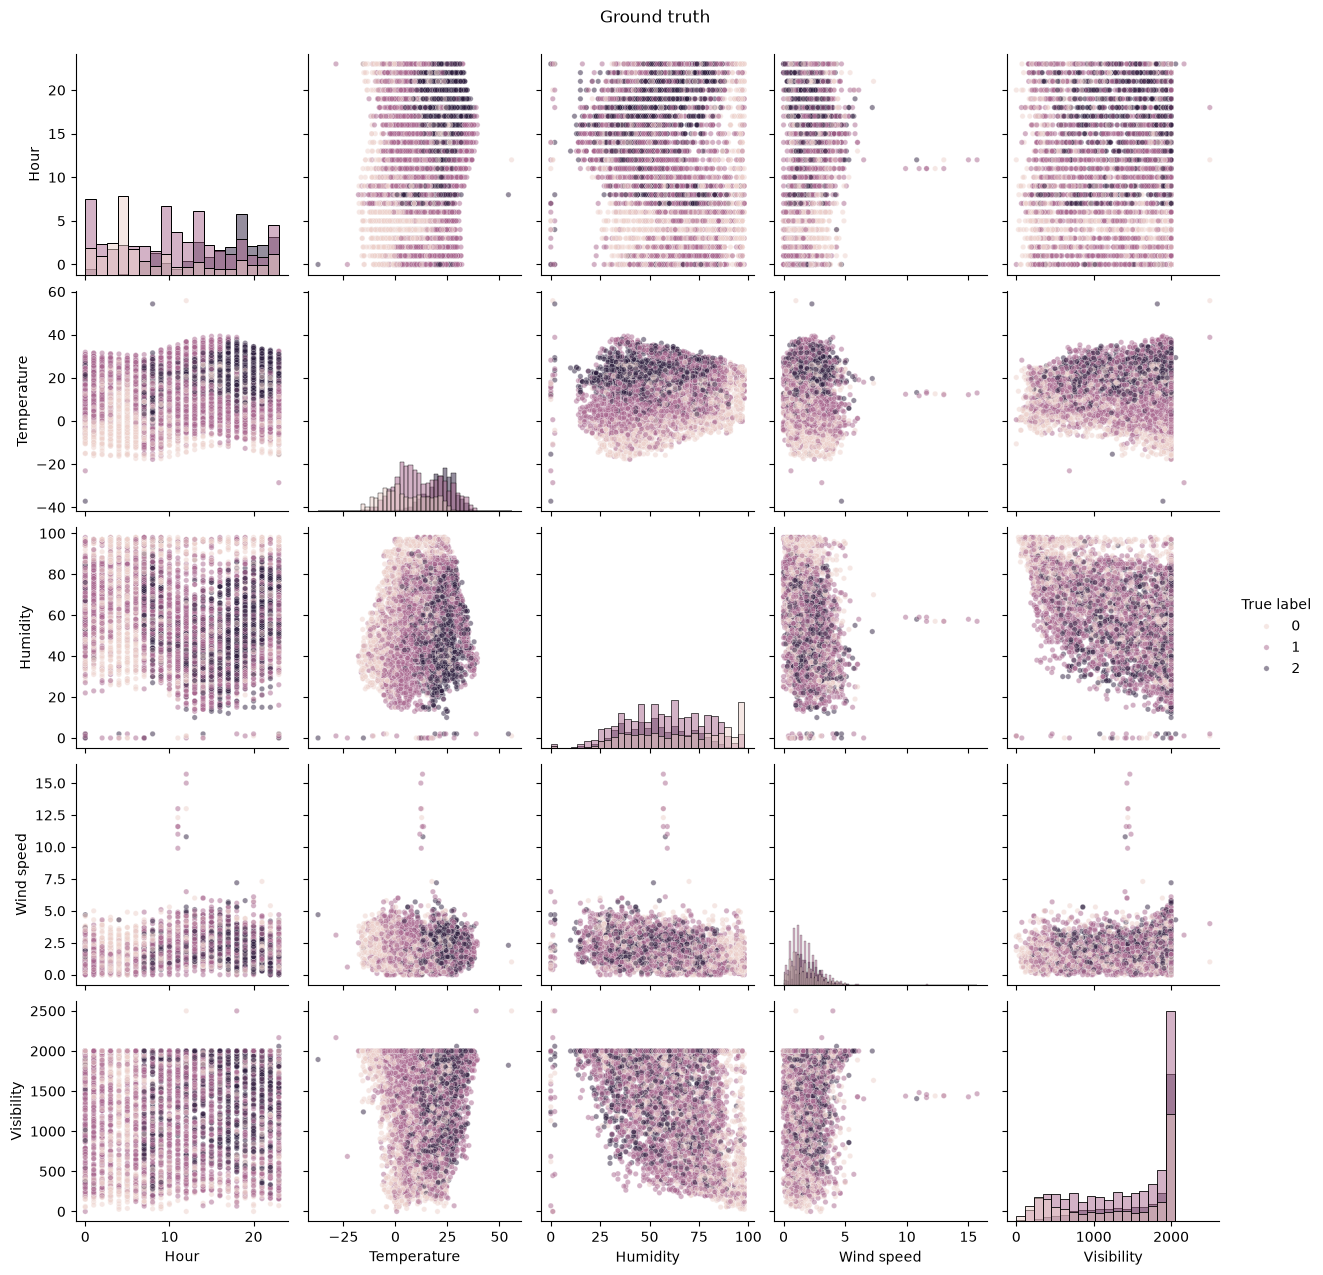

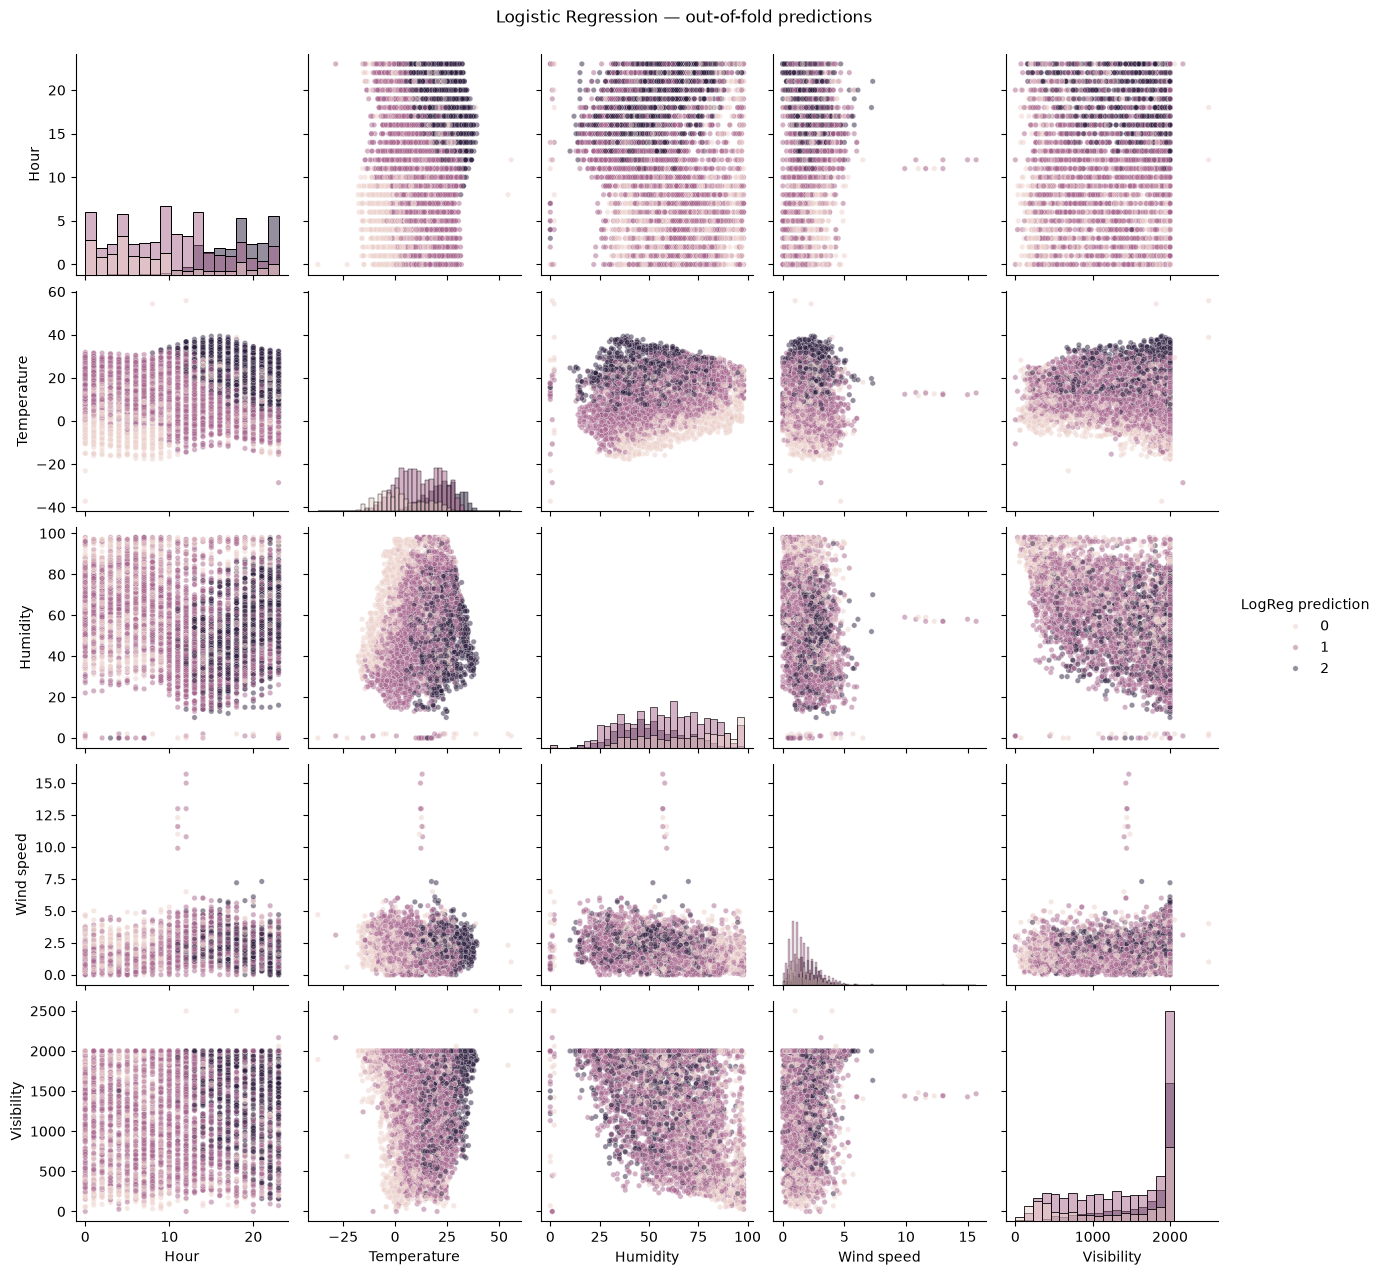

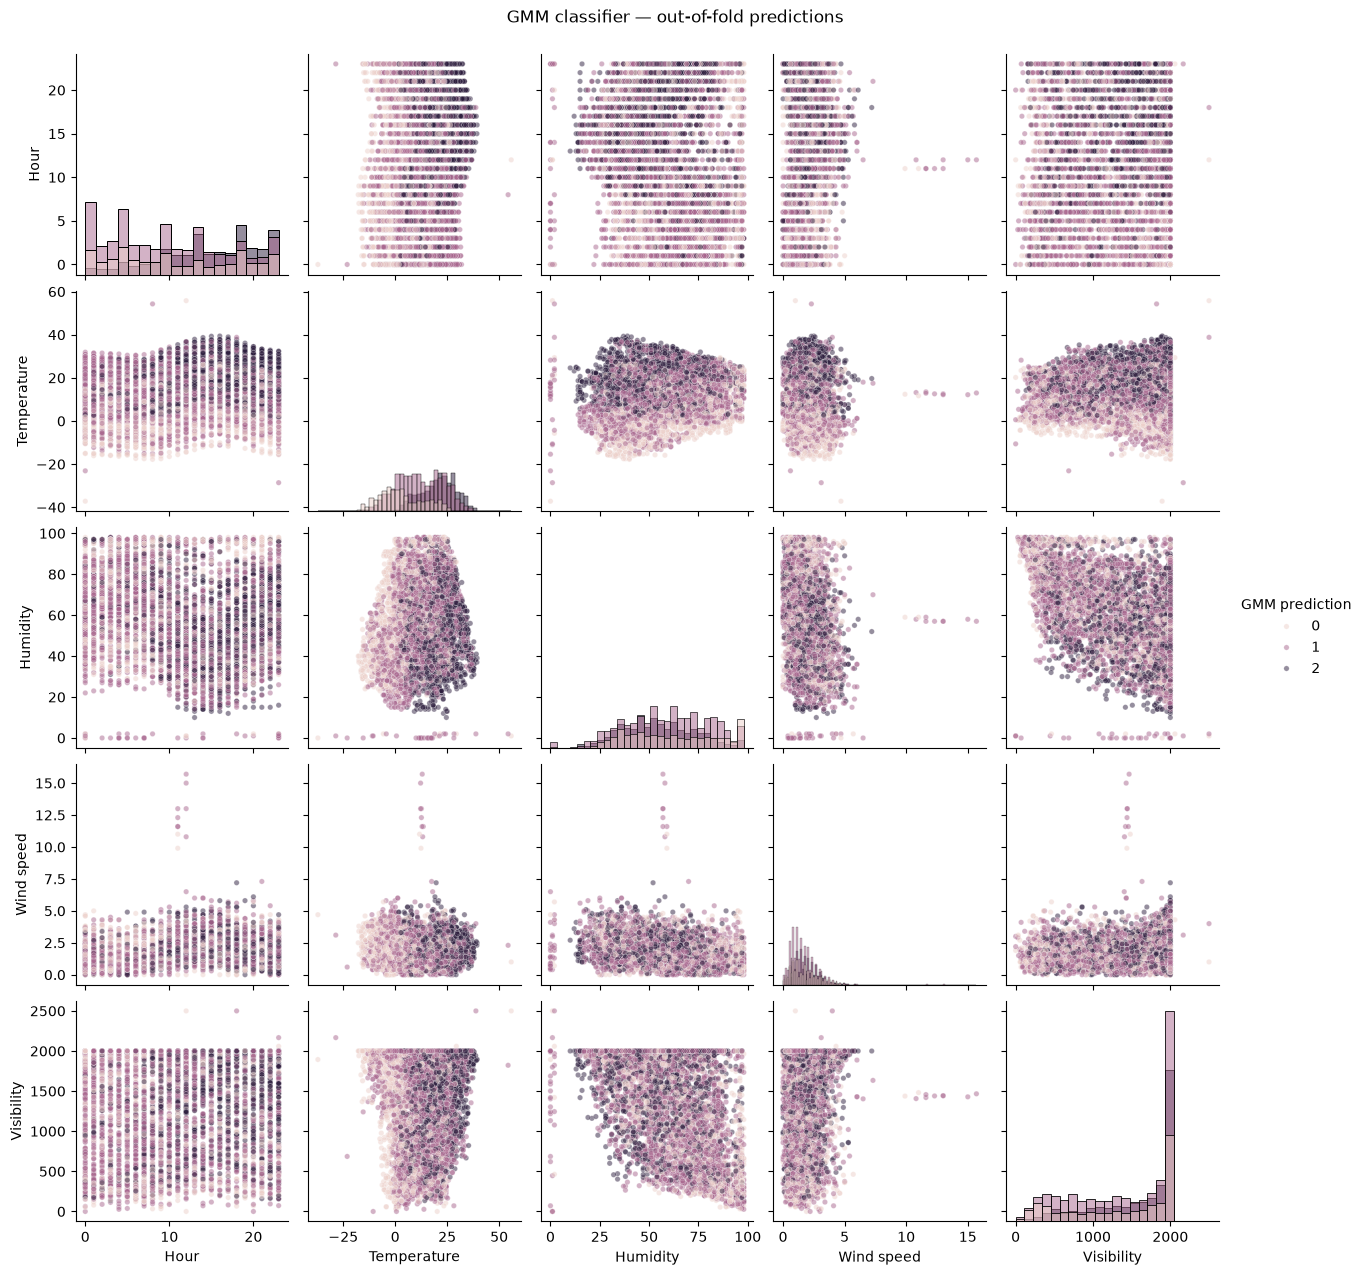

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

oof_logreg = cross_val_predict(logregr_pipeline, X, y, cv=cv, groups=groups, n_jobs=-1)
oof_gmm = cross_val_predict(gmm_pipeline, X, y, cv=cv, groups=groups, n_jobs=-1)

pred_logreg = le.inverse_transform(oof_logreg)
pred_gmm = le.inverse_transform(oof_gmm)

# logregr_pipeline.fit(X, y)
# gmm_pipeline.fit(X, y)
# pred_logreg = le.inverse_transform(logregr_pipeline.predict(X))
# pred_gmm = le.inverse_transform(gmm_pipeline.predict(X))

plot_cols = num_cols[:5]

plot_df = X[plot_cols].copy()
plot_df["True label"] = y_raw.values
plot_df["LogReg prediction"] = pred_logreg
plot_df["GMM prediction"] = pred_gmm

for hue_col, title in [
    ("True label", "Ground truth"),
    ("LogReg prediction", "Logistic Regression — out-of-fold predictions"),
    ("GMM prediction", "GMM classifier — out-of-fold predictions"),
]:
    g = sns.pairplot(
        plot_df,
        vars=plot_cols,
        hue=hue_col,
        diag_kind="hist",
        plot_kws={"alpha": 0.5, "s": 15},
    )
    g.fig.suptitle(title, y=1.02)
    plt.show()

In [9]:
from sklearn import set_config
set_config(display="diagram")

final_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('weather_imputer', ...), ('prep', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
,features,"['Temperature', 'Solar Radiation', ...]"
,date_column,'Date'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Th